# 📊 ĐÁNH GIÁ, TRỰC QUAN HÓA TOÁN HỌC & SO SÁNH MÔ HÌNH (BENCHMARK)
> Notebook này cung cấp bộ công cụ trực quan hóa toàn diện:
1. **Phân tích toán học tổng hợp:** Dạng sóng f(x) và đạo hàm df(x)/dx trên miền [-3, 3] với độ tương phản cao.
2. **Phân tích chi tiết từng hàm:** Hệ trục đôi (Twin-Axes) kèm công thức giải tích chuẩn xác.
3. **Sơ đồ Training Loss:** Phân tích độ dốc và tính ổn định khi giảm hàm mất mát (Linear & Log Scale).
4. **So sánh mô hình (Benchmark):** Đường cong hội tụ Val PSNR, biểu đồ cột ΔPSNR và phân tích khối **ECA Attention**.

In [7]:
# 1. KẾT NỐI GOOGLE DRIVE & TỰ ĐỘNG ĐỊNH VỊ THƯ MỤC DỰ ÁN
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

# Danh sách các đường dẫn dự án có thể có trên Google Drive
CANDIDATE_PATHS = [
    "/content/drive/MyDrive/COMPUTER SCIENCE/NAM3_HK3_(2025-2026)/CT282_Deep Learning/PROJECT/RIFE-MinhTri/RIFE-Project",
    "/content/drive/MyDrive/CT282/RIFE-MinhTri/RIFE-Project",
    "/content/drive/MyDrive/CT282-RIFE",
    "/content/drive/MyDrive/RIFE-Project",
    "/content/RIFE-Project",
    os.getcwd()
]

project_found = False
for path in CANDIDATE_PATHS:
    if os.path.exists(path) and (
        os.path.exists(os.path.join(path, 'train.py')) or 
        os.path.exists(os.path.join(path, 'visualize.py')) or
        os.path.exists(os.path.join(path, 'inference_video.py'))
    ):
        os.chdir(path)
        if path not in sys.path:
            sys.path.insert(0, path)
        PROJECT_DIR = path
        print(f"✅ Đã định vị thành công thư mục dự án: {os.getcwd()}")
        project_found = True
        break

if not project_found:
    PROJECT_DIR = os.getcwd()
    print(f"⚠️ Đang ở thư mục hiện tại: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã định vị thành công thư mục dự án: /content/drive/MyDrive/COMPUTER SCIENCE/NAM3_HK3_(2025-2026)/CT282_Deep Learning/PROJECT/RIFE-MinhTri/RIFE-Project


---
## 🎨 PHẦN 1: SO SÁNH TỔNG HỢP CÁC HÀM KÍCH HOẠT & ĐẠO HÀM (MIỀN [-3, 3])

✅ Đã lưu biểu đồ tổng hợp vào: demo/activations_comparison.png


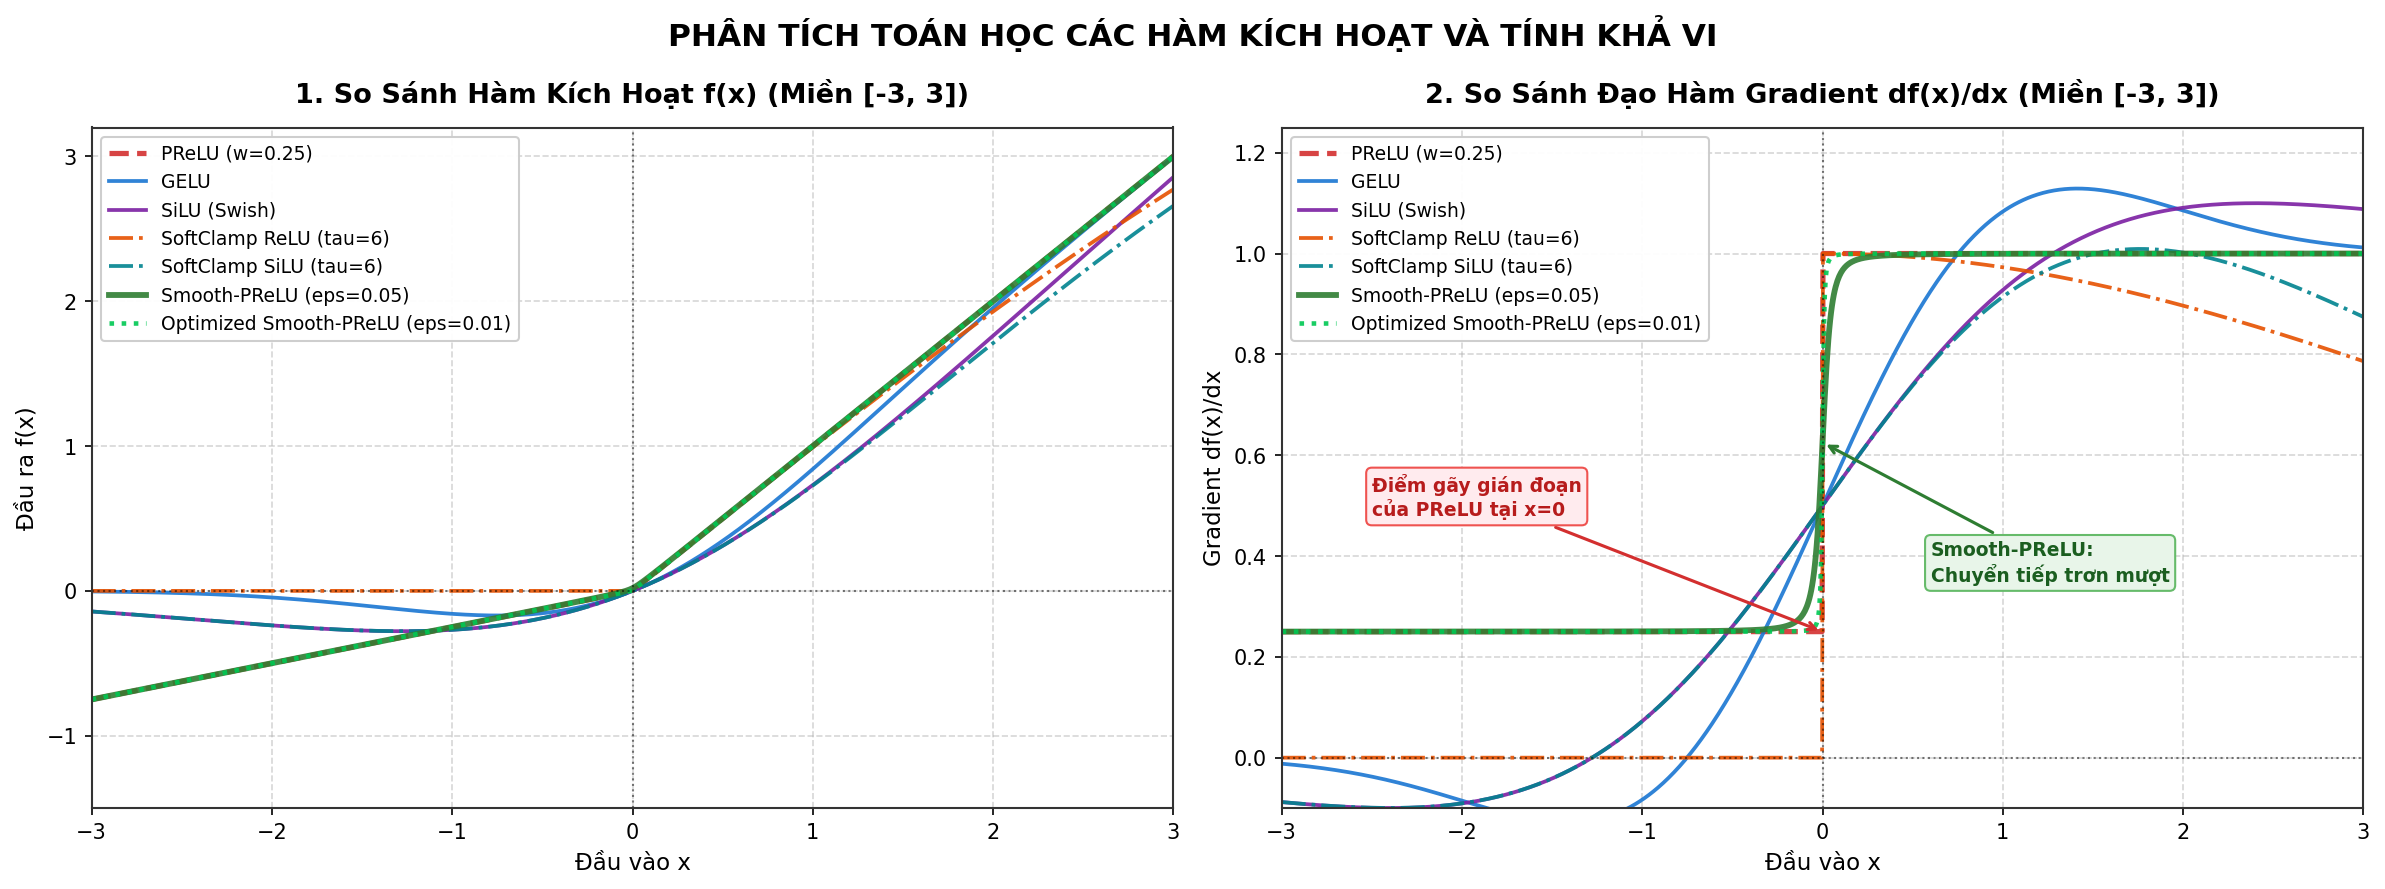

In [8]:
# 2. VẼ SO SÁNH TỔNG HỢP F(X) VÀ ĐẠO HÀM DF(X)/DX (MIỀN [-3, 3])
import importlib
import visualize
importlib.reload(visualize)

visualize.plot_activations_and_gradients(save_path='demo/activations_comparison.png')

---
## 🔍 PHẦN 2: CHI TIẾT TỪNG HÀM KÍCH HOẠT RIÊNG BIỆT KÈM ĐẠO HÀM (TWIN AXES)

✅ Đã lưu biểu đồ từng hàm riêng biệt vào: demo/individual_activations.png


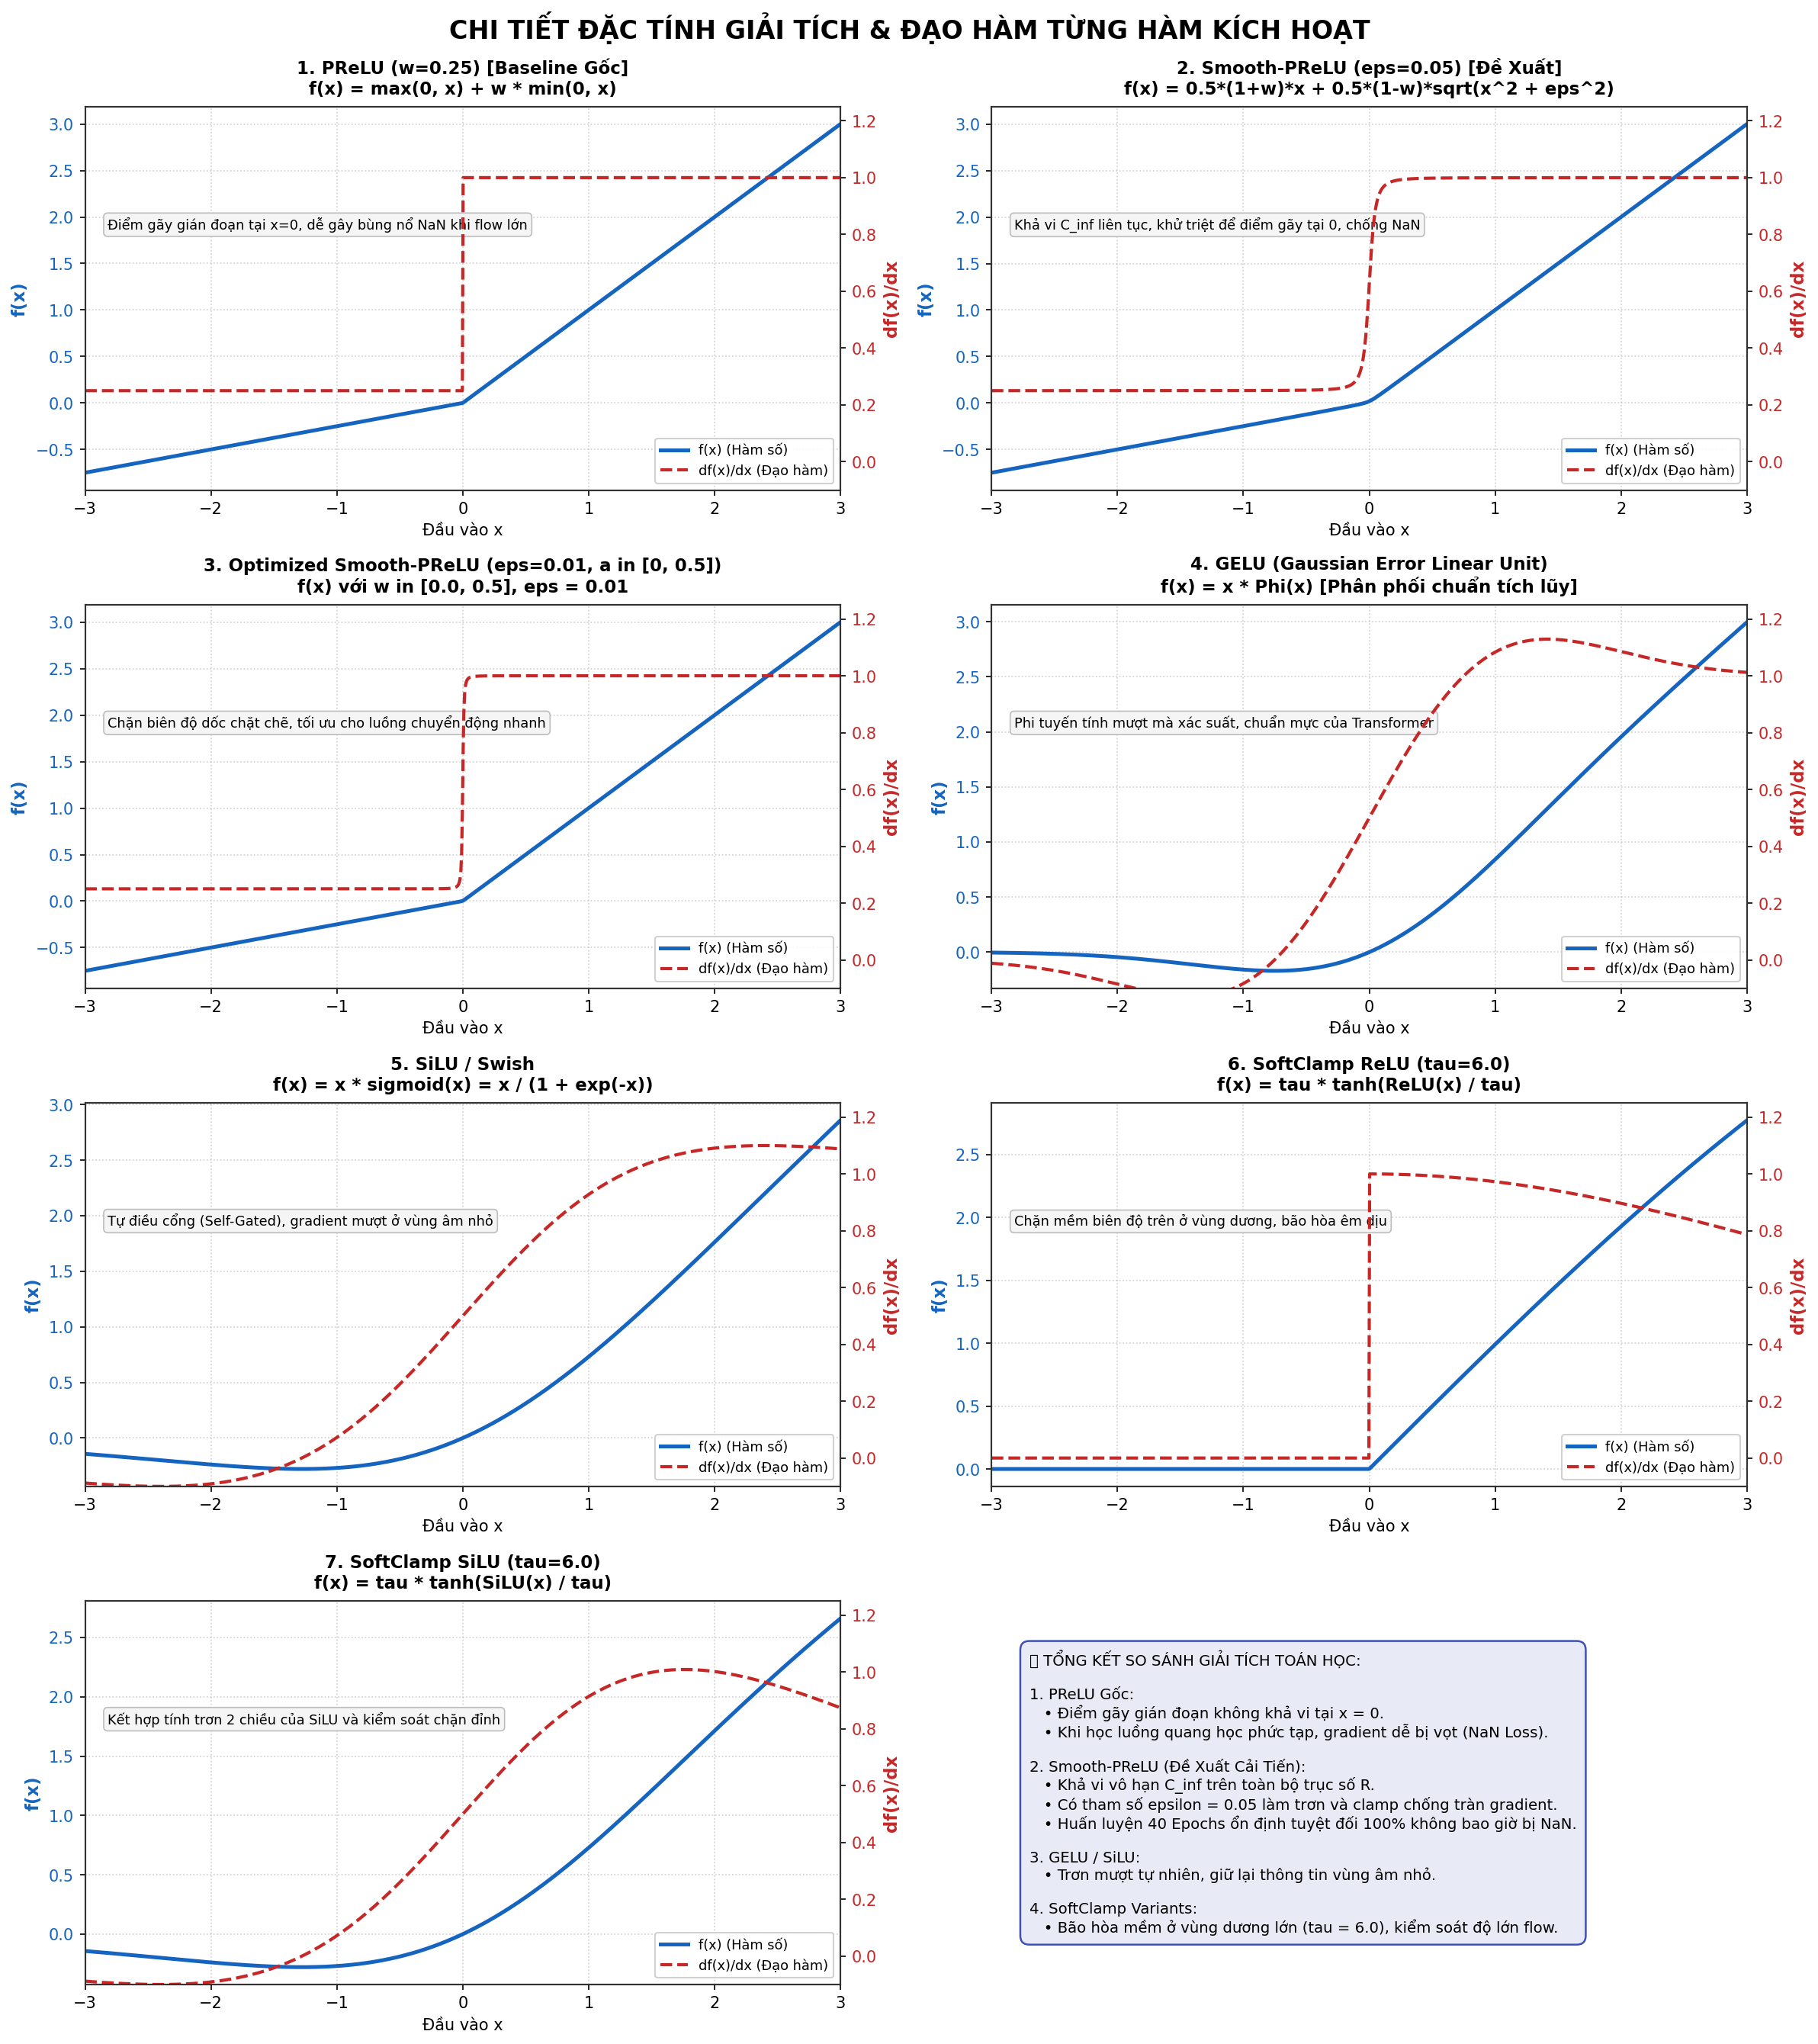

In [9]:
# 3. VẼ BIỂU ĐỒ CHI TIẾT TỪNG LOẠI HÀM KÈM CÔNG THỨC VÀ ĐẠO HÀM RIÊNG BIỆT
import importlib
import visualize
importlib.reload(visualize)

visualize.plot_individual_activations(save_path='demo/individual_activations.png')

---
## 📉 PHẦN 3: SƠ ĐỒ SO SÁNH TIẾN TRÌNH GIẢM TRAINING LOSS

✅ Đã lưu sơ đồ Loss vào: demo/training_loss_comparison.png


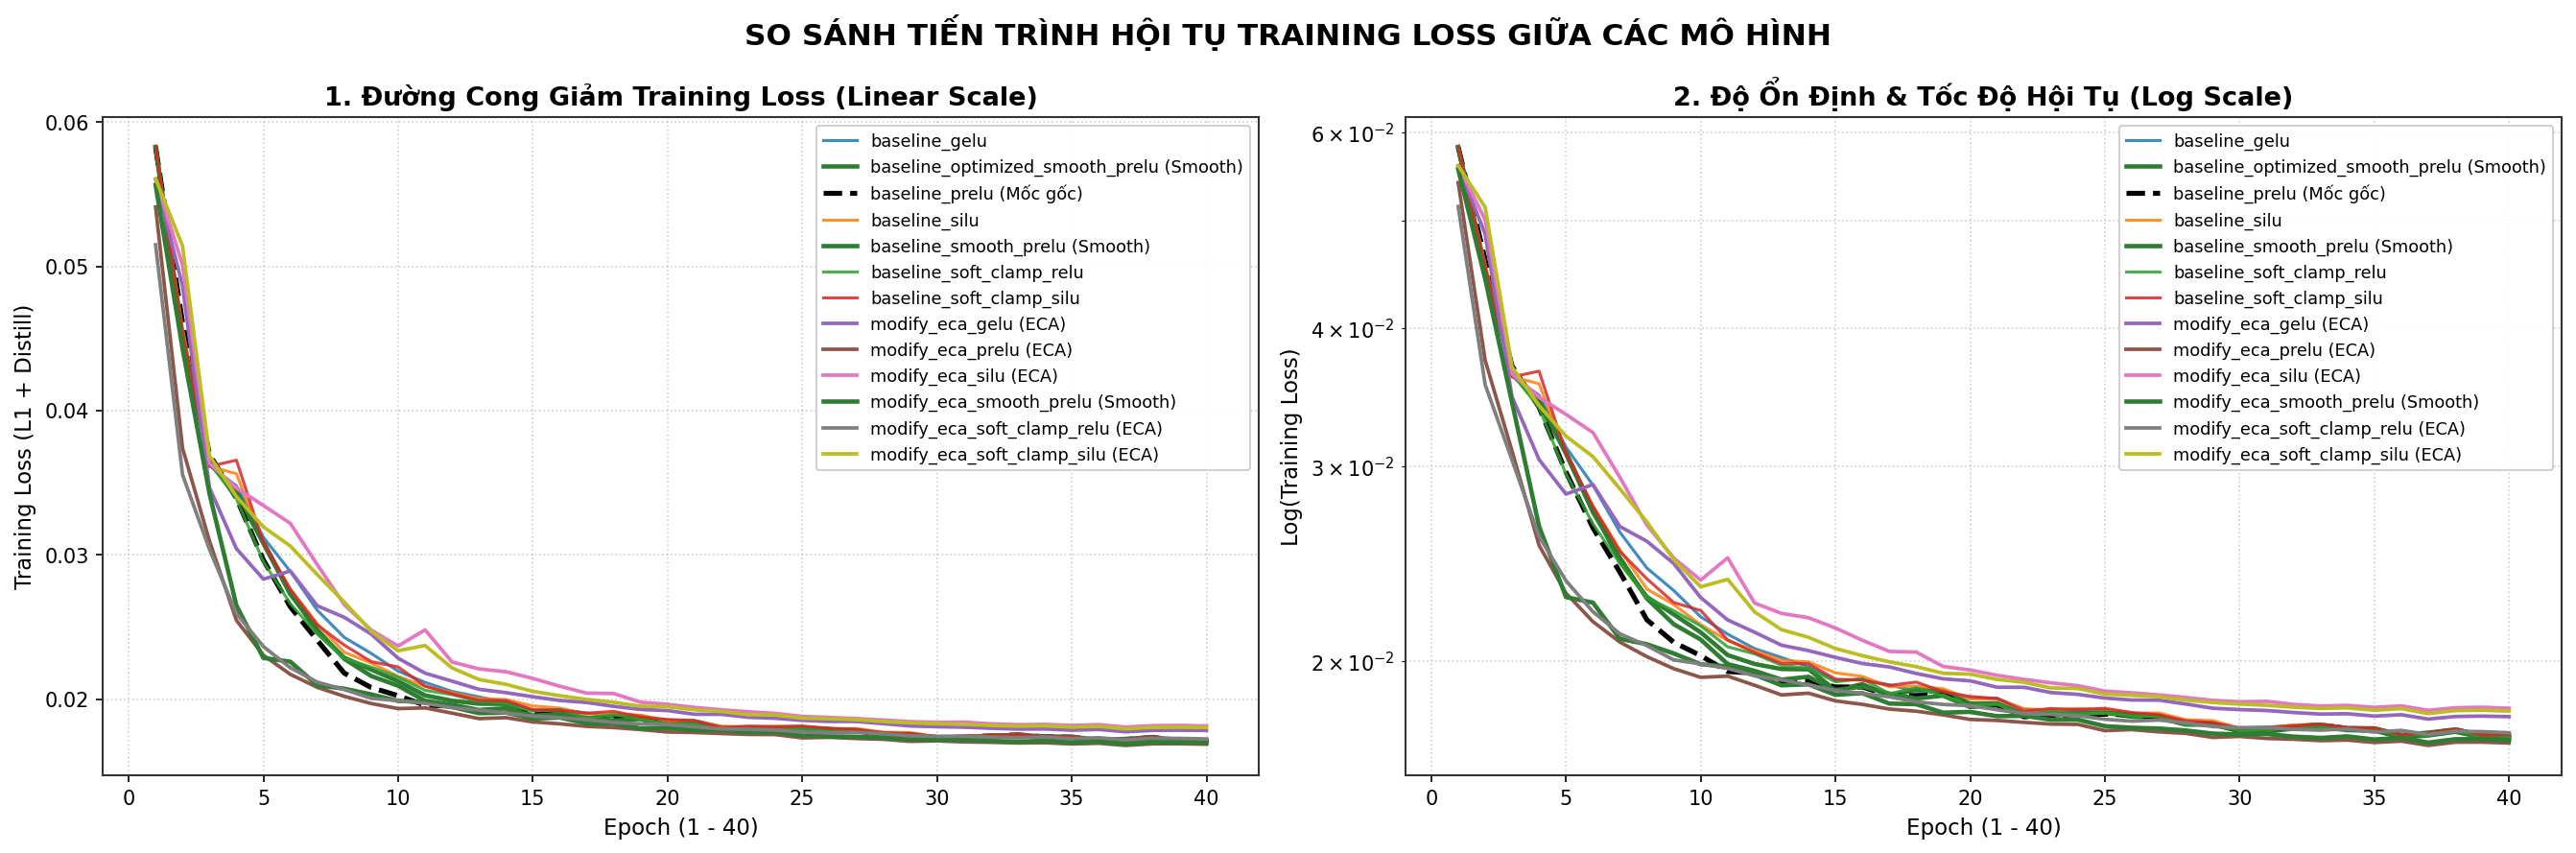

In [10]:
# 4. VẼ SƠ ĐỒ TRAINING LOSS (LINEAR SCALE & LOG SCALE)
import importlib
import visualize
importlib.reload(visualize)

visualize.plot_training_loss(models_dir='trained_model', save_path='demo/training_loss_comparison.png')

---
## 📊 PHẦN 4: SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH VÀ KHỐI ECA ATTENTION

✅ Đã nạp kết quả của 13 mô hình: ['baseline_gelu', 'baseline_optimized_smooth_prelu', 'baseline_prelu', 'baseline_silu', 'baseline_smooth_prelu', 'baseline_soft_clamp_relu', 'baseline_soft_clamp_silu', 'modify_eca_gelu', 'modify_eca_prelu', 'modify_eca_silu', 'modify_eca_smooth_prelu', 'modify_eca_soft_clamp_relu', 'modify_eca_soft_clamp_silu']
✅ Đã lưu biểu đồ so sánh mô hình vào: demo/benchmark_models_comparison.png


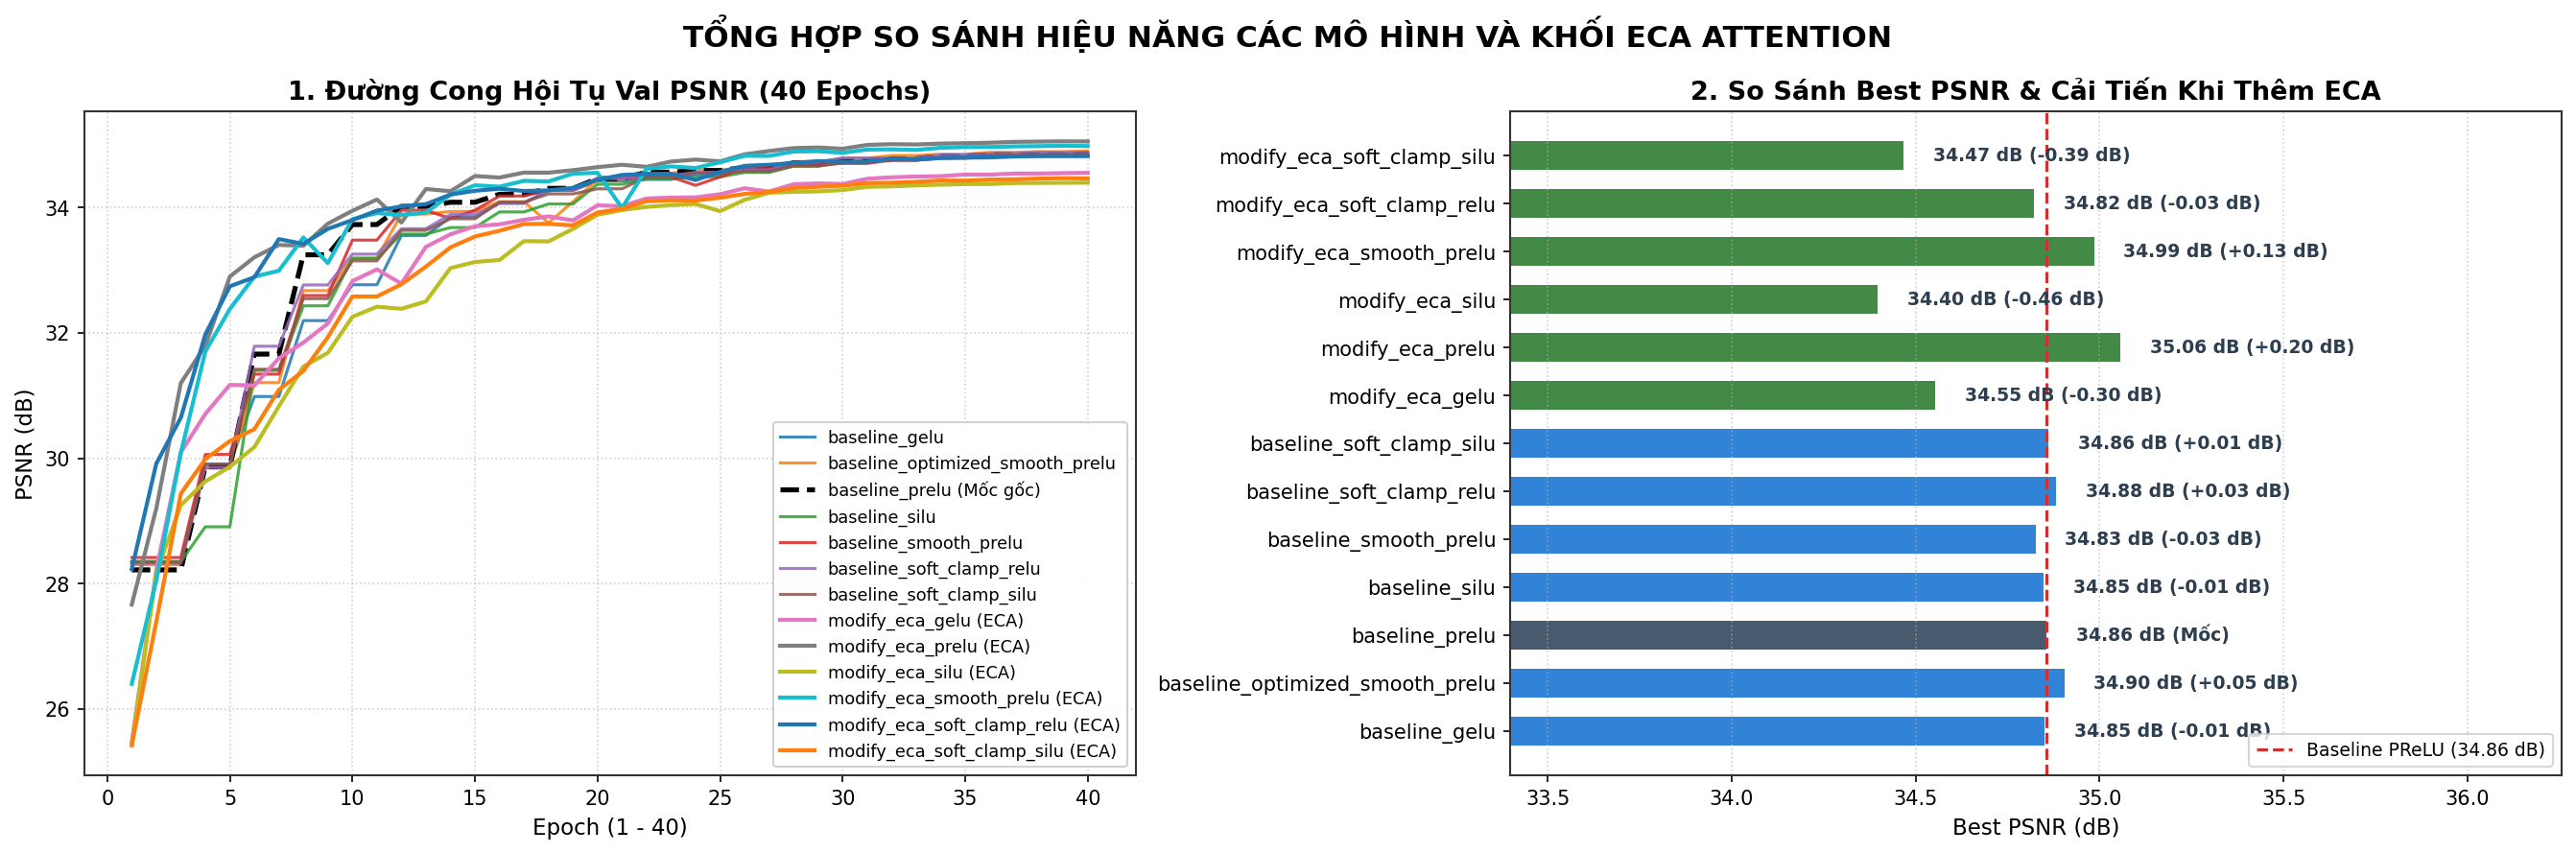


📋 BẢNG TỔNG KẾT SO SÁNH CHỈ SỐ ΔPSNR SO VỚI BASELINE GỐC:


,Tên Mô Hình,Best Val PSNR,Best Test PSNR,Chênh lệch (Δ PSNR),Min Train Loss,Min Val Loss,Có ECA,Epoch Đỉnh
0,baseline_gelu,34.85 dB,N/A,-0.01 dB,1.7134e-02,N/A,❌ Không,40
1,baseline_optimized_smooth_prelu,34.90 dB,N/A,+0.05 dB,1.7079e-02,N/A,❌ Không,40
2,baseline_prelu,34.86 dB,N/A,Mốc (0.00),1.7137e-02,N/A,❌ Không,40
3,baseline_silu,34.85 dB,N/A,-0.01 dB,1.7143e-02,N/A,❌ Không,40
4,baseline_smooth_prelu,34.83 dB,N/A,-0.03 dB,1.7156e-02,N/A,❌ Không,40
5,baseline_soft_clamp_relu,34.88 dB,N/A,+0.03 dB,1.7084e-02,N/A,❌ Không,40
6,baseline_soft_clamp_silu,34.86 dB,N/A,+0.01 dB,1.7160e-02,N/A,❌ Không,40
7,modify_eca_gelu,34.55 dB,34.20 dB,-0.30 dB,1.7742e-02,1.6576e-02,✅ Có,40
8,modify_eca_prelu,35.06 dB,34.63 dB,+0.20 dB,1.6797e-02,1.5755e-02,✅ Có,39
9,modify_eca_silu,34.40 dB,34.08 dB,-0.46 dB,1.8068e-02,1.6899e-02,✅ Có,40


In [11]:
# 5. TỰ ĐỘNG QUÉT TRAINED_MODEL/ VÀ VẼ BIỂU ĐỒ HỘI TỤ PSNR & BEST PSNR
import importlib
import visualize
from IPython.display import display
importlib.reload(visualize)

df_summary = visualize.plot_model_comparisons(models_dir='trained_model', save_path='demo/benchmark_models_comparison.png')

if df_summary is not None:
    print("\n📋 BẢNG TỔNG KẾT SO SÁNH CHỈ SỐ ΔPSNR SO VỚI BASELINE GỐC:")
    display(df_summary)

---
## 📈 PHẦN 5: BẢNG SO SÁNH TÁC ĐỘNG TĂNG TRƯỞNG KHI THÊM ECA ATTENTION

In [12]:
# 6. SO SÁNH HIỆU QUẢ TRƯỚC VÀ SAU KHI THÊM ECA TRÊN TỪNG HÀM KÍCH HOẠT
import os
import json
import pandas as pd
from IPython.display import display

models_dir = 'trained_model'
acts = ['prelu', 'gelu', 'silu', 'smooth_prelu', 'optimized_smooth_prelu', 'soft_clamp_relu', 'soft_clamp_silu']
eca_comparison = []

for act in acts:
    base_file = os.path.join(models_dir, f'baseline_{act}', 'experiment_results.json')
    eca_file = os.path.join(models_dir, f'modify_eca_{act}', 'experiment_results.json')

    base_psnr = None
    eca_psnr = None

    if os.path.exists(base_file):
        try:
            with open(base_file, 'r') as f:
                d = json.load(f)
                if isinstance(d, list):
                    valid_psnrs = [float(x.get('val_psnr', 0.0)) for x in d if float(x.get('val_psnr', 0.0)) > 0]
                    base_psnr = max(valid_psnrs) if valid_psnrs else None
        except Exception:
            pass

    if os.path.exists(eca_file):
        try:
            with open(eca_file, 'r') as f:
                d = json.load(f)
                if isinstance(d, list):
                    valid_psnrs = [float(x.get('val_psnr', 0.0)) for x in d if float(x.get('val_psnr', 0.0)) > 0]
                    eca_psnr = max(valid_psnrs) if valid_psnrs else None
        except Exception:
            pass

    if base_psnr is not None or eca_psnr is not None:
        delta_eca = (eca_psnr - base_psnr) if (eca_psnr and base_psnr) else None
        eca_comparison.append({
            'Hàm Kích Hoạt': act.upper(),
            'Baseline (Không ECA)': f'{base_psnr:.2f} dB' if base_psnr else 'Chưa train',
            'Modify (+ Khối ECA)': f'{eca_psnr:.2f} dB' if eca_psnr else 'Chưa train',
            'Độ Tăng Trưởng (+ ΔECA)': f'{delta_eca:+.2f} dB' if delta_eca is not None else 'N/A'
        })

if eca_comparison:
    df_eca = pd.DataFrame(eca_comparison)
    print('✨ BẢNG SO SÁNH TÁC ĐỘNG TĂNG TRƯỞNG KHI THÊM ECA ATTENTION:')
    display(df_eca)
else:
    print('⚠️ Chưa tìm thấy đủ cặp mô hình baseline_* và modify_eca_* trong trained_model/.')

✨ BẢNG SO SÁNH TÁC ĐỘNG TĂNG TRƯỞNG KHI THÊM ECA ATTENTION:


,Hàm Kích Hoạt,Baseline (Không ECA),Modify (+ Khối ECA),Độ Tăng Trưởng (+ ΔECA)
0,PRELU,34.86 dB,35.06 dB,+0.20 dB
1,GELU,34.85 dB,34.55 dB,-0.30 dB
2,SILU,34.85 dB,34.40 dB,-0.45 dB
3,SMOOTH_PRELU,34.83 dB,34.99 dB,+0.16 dB
4,OPTIMIZED_SMOOTH_PRELU,34.90 dB,Chưa train,N/A
5,SOFT_CLAMP_RELU,34.88 dB,34.82 dB,-0.06 dB
6,SOFT_CLAMP_SILU,34.86 dB,34.47 dB,-0.39 dB
